# Electrical Time Series Data Classification with SE-TSNet

## Prepare Notebook

In [1]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Imports

In [2]:
import os
import numpy as np
import src.data.io as data_io
from src.data.split import stratified_split
from src.utils.visualization import plot_training_history
from src.deployment.export import (
    export_tflite_int8, 
    tflite_to_c_header
)
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)
from tensorflow.keras.layers import (
    Input, 
    Conv1D, 
    GlobalAveragePooling1D, 
    Dense, 
    Multiply, 
    Reshape
)


from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    classification_report
)

## Data Preparation

### Data Loading

In [3]:
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [4]:
train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## SE-TSNet Model

### Building

In [5]:
def squeeze_excitation_block(input_tensor, ratio=8):
    filters = input_tensor.shape[-1]

    se = GlobalAveragePooling1D()(input_tensor)
    se = Dense(filters // ratio, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)
    se = Reshape((1, filters))(se)

    return Multiply()([input_tensor, se])

def build_se_tsnet(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = Conv1D(filters=32, kernel_size=3, padding="same", activation="relu")(inputs)
    x = squeeze_excitation_block(x)

    x = Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
    x = squeeze_excitation_block(x)

    x = Conv1D(filters=128, kernel_size=7, padding="same", activation="relu")(x)
    x = squeeze_excitation_block(x)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model

se_tsnet_model = build_se_tsnet()

se_tsnet_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

se_tsnet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 30, 5)]              0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 30, 32)               512       ['input_1[0][0]']             
                                                                                                  
 global_average_pooling1d (  (None, 32)                   0         ['conv1d[0][0]']              
 GlobalAveragePooling1D)                                                                          
                                                                                                  
 dense (Dense)               (None, 4)                    132       ['global_average_pooling1d

### Training

In [6]:
def train_se_tsnet_model(model, X_train, y_train, X_val, y_val,
              epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_se_tsnet_model_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_se_tsnet_model(se_tsnet_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=16,
                    save_best_model=True)

Epoch 1/50
1695/1695 [==============================] - 3s 2ms/step - loss: 0.4839 - accuracy: 0.8341 - val_loss: 0.3511 - val_accuracy: 0.8489 - lr: 0.0010
Epoch 2/50
 111/1695 [>.............................] - ETA: 2s - loss: 0.3819 - accuracy: 0.8615

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1695/1695 [==============================] - 3s 2ms/step - loss: 0.2342 - accuracy: 0.9140 - val_loss: 0.1999 - val_accuracy: 0.9249 - lr: 0.0010
Epoch 3/50
1695/1695 [==============================] - 3s 2ms/step - loss: 0.1849 - accuracy: 0.9330 - val_loss: 0.1698 - val_accuracy: 0.9411 - lr: 0.0010
Epoch 4/50
1695/1695 [==============================] - 3s 2ms/step - loss: 0.1598 - accuracy: 0.9413 - val_loss: 0.1685 - val_accuracy: 0.9423 - lr: 0.0010
Epoch 5/50
1695/1695 [==============================] - 3s 2ms/step - loss: 0.1372 - accuracy: 0.9476 - val_loss: 0.1109 - val_accuracy: 0.9593 - lr: 0.0010
Epoch 6/50
1695/1695 [==============================] - 3s 2ms/step - loss: 0.1203 - accuracy: 0.9553 - val_loss: 0.1725 - val_accuracy: 0.9450 - lr: 0.0010
Epoch 7/50
1695/1695 [==============================] - 3s 2ms/step - loss: 0.1076 - accuracy: 0.9574 - val_loss: 0.1734 - val_accuracy: 0.9391 - lr: 0.0010
Epoch 8/50
1695/1695 [==============================] - 3s 2ms/step -

## Evaluation

### Training Performance

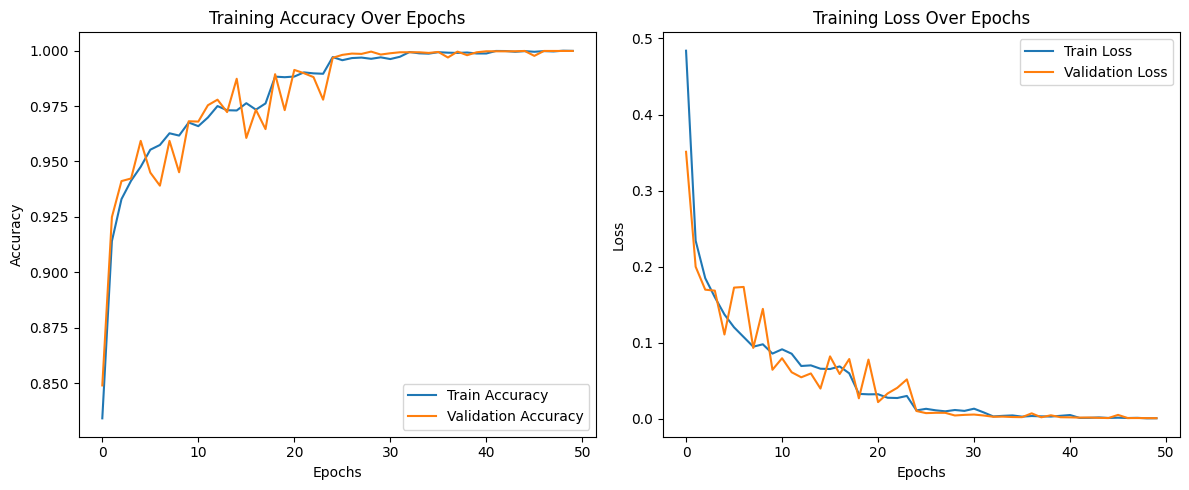

In [7]:
plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 0s 901us/step

Test Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    1.0000    1.0000       188
           2     1.0000    1.0000    1.0000       508
           3     1.0000    1.0000    1.0000       373
           4     1.0000    1.0000    1.0000      2603
           5     0.9990    1.0000    0.9995      1938
           6     1.0000    1.0000    1.0000       511
           7     1.0000    0.9796    0.9897        98
           8     1.0000    1.0000    1.0000       463

    accuracy                         0.9998      8471
   macro avg     0.9999    0.9977    0.9988      8471
weighted avg     0.9998    0.9998    0.9998      8471



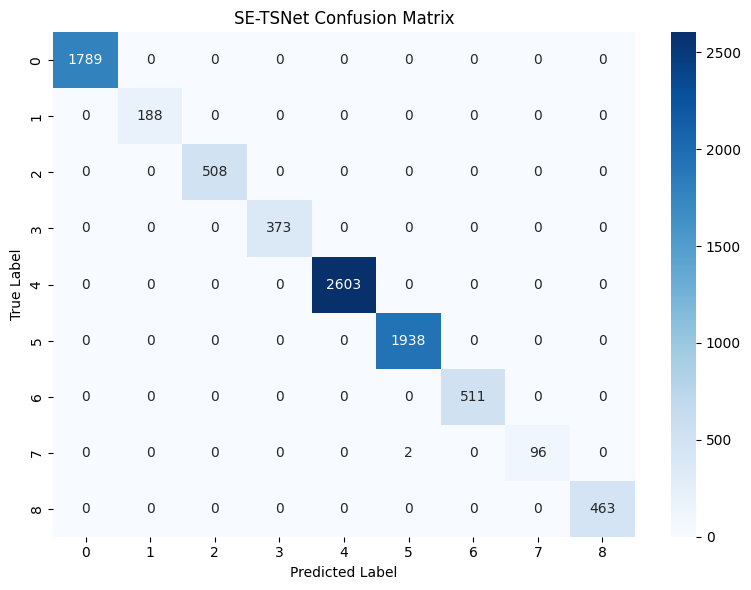

In [8]:
accuracy, report, y_pred = evaluate_classification(
    se_tsnet_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="SE-TSNet Confusion Matrix"
)

### Model Saving and Size Check

In [9]:
se_tsnet_model.save("../../models/se_tsnet_model.h5")

model_size = os.path.getsize("../../models/se_tsnet_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 0.96 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [10]:
TFLITE_MODEL_PATH = "../../models/se_tsnet_model_quantized.tflite"

export_tflite_int8(
    model=se_tsnet_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpcwx4an8r/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpcwx4an8r/assets


Quantized model saved: ../../models/se_tsnet_model_quantized.tflite (91.99 KB)


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-01 02:35:04.397823: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-01 02:35:04.397837: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-01 02:35:04.397995: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpcwx4an8r
2026-03-01 02:35:04.399173: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-01 02:35:04.399177: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpcwx4an8r
2026-03-01 02:35:04.401218: I tensorflow/compiler/m

b' \x00\x00\x00TFL3\x00\x00\x00\x00\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x80\x00\x00\x00\xd8\x00\x00\x00\xb0/\x01\x00\xc0/\x01\x00\xdcn\x01\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00v\xc8\xfe\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x9c\xff\xff\xffE\x00\x00\x00\x04\x00\x00\x00\x07\x00\x00\x00dense_6\x00\x01\x00\x00\x00\x04\x00\x00\x00:\xca\xfe\xff\x04\x00\x00\x00\x07\x00\x00\x00input_1\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xffH\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00G\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00I\x00\x00\x00\xd4.\x01\x00\xcc.\x01\x00\xb8.\x01\x00\x9c.\x01\x00\x88.\x01\x00t.\x01\x00l.\x01\x00X.\x01\x00<.\x01\x00(.\x01\x00\x0c.\x01\x00\xf8-\x01\x00\xc4-\x01\x004)\x01\x00$\'\x01\x00\x14\x1f\x01\x00\xc

### Evaluation

In [11]:
interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite model prediction completed.


### Test Classification Report

In [12]:
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9919
Precision: 0.9924
Recall: 0.9919
F1-score: 0.9920

Classification Report:
              precision    recall  f1-score   support

           0     0.9917    1.0000    0.9958      1789
           1     0.9895    1.0000    0.9947       188
           2     1.0000    1.0000    1.0000       508
           3     0.8923    1.0000    0.9431       373
           4     1.0000    0.9827    0.9913      2603
           5     0.9995    1.0000    0.9997      1938
           6     1.0000    0.9706    0.9851       511
           7     0.9684    0.9388    0.9534        98
           8     0.9935    0.9935    0.9935       463

    accuracy                         0.9919      8471
   macro avg     0.9817    0.9873    0.9841      8471
weighted avg     0.9924    0.9919    0.9920      8471



### Confusion Matrix

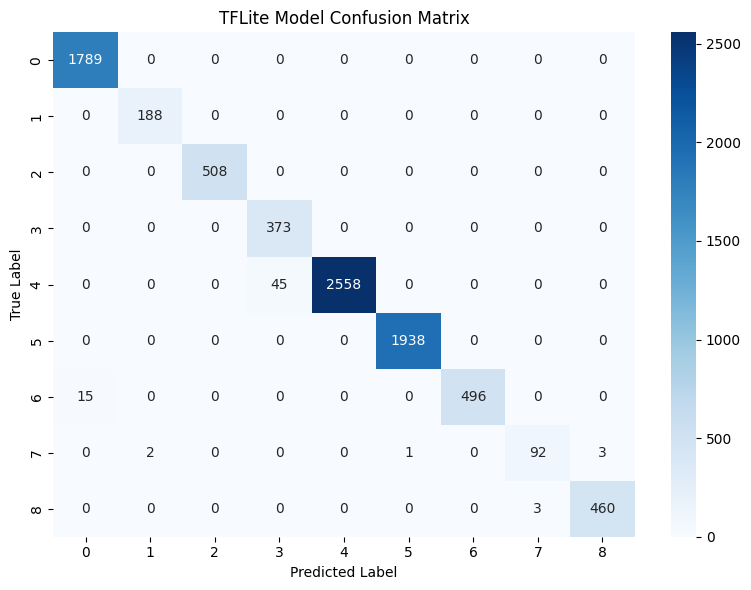

In [13]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [14]:
tflite_model_path = "../../models/se_tsnet_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 91.99 KB


### ESP32 Compatible Header File Creation

In [15]:
tflite_to_c_header(
    "../../models/se_tsnet_model_quantized.tflite",
    var_name="se_tsnet_model"
)

C header created: ../../models/se_tsnet_model_quantized.h
Size: 91.99 KB


PosixPath('../../models/se_tsnet_model_quantized.h')